# Window dependence of the mean central mode count
Fixed $N_x=20$, $N_y=32$, all 100 hard-wall pure-state endpoints at cycle 64. Scan the symmetric spectral window $[-L,L]$, average all 32 periodic origins within each trajectory, then average trajectories. Fit subsystem widths $A_y=5,\ldots,16$. This notebook reads the validated cached spectra; no diagonalization or circuit simulation is needed.

In [1]:
import os
if 'AVAILABLE_CPUS' not in globals():AVAILABLE_CPUS=sorted(os.sched_getaffinity(0))
CPU_RANGE=(8,15) # editable inclusive range
selected=list(range(CPU_RANGE[0],CPU_RANGE[1]+1))
assert set(selected).issubset(AVAILABLE_CPUS)
os.sched_setaffinity(0,selected)
for key in ('OPENBLAS_NUM_THREADS','MKL_NUM_THREADS','OMP_NUM_THREADS'):os.environ[key]=str(len(selected))
from threadpoolctl import threadpool_limits
limits=threadpool_limits(len(selected))
print('Allocated CPUs:',selected)

Allocated CPUs: [8, 9, 10, 11, 12, 13, 14, 15]


## Estimator and fit
For each trajectory $s$ and origin $y_0$, use eigenvalues $\lambda_{s,y_0,j}$ of $Q_A=2G_A-\mathbf{1}_A$, where $G_A=F_AF_A^\dagger$ is the restricted occupation correlation matrix. Define
$$N_{s,L}(A_y)=\frac1{32}\sum_{y_0=0}^{31}\sum_j\mathbf{1}_{|\lambda_{s,y_0,j}|\le L},\qquad\overline N_L=\frac1{100}\sum_s N_{s,L}.$$
The summary percentages are evaluated at the half-system cut $A_y=16$: divide its mean window count by 1280 for the fraction of full-system modes, or by 640 for the fraction of subsystem modes. These are fractions of all modes, including the pure endpoints; they are not conditional fractions of mixed modes. Percentages vary with subsystem width, and the curves CSV also records every width.

This is a mean number of modes, with no division by the number of retained modes and no unit-area density normalization. Every x and both orbitals are included; periodic y cuts use $i=40y+2x+\mu$. All default windows are strictly inside $(-1,1)$, so no near-pure-mode cutoff or eigenvalue clipping is needed.

Fit $\overline N_L=a(L)+b(L)\log d$, with $d=(32/\pi)\sin(\pi A_y/32)$ and natural logarithm, using ordinary least squares over widths 5–16. The linear fit operator is applied to each trajectory's origin-averaged curve; coefficient means give the ensemble fit and coefficient SEMs retain all cross-width correlations. The same trajectories contribute to every L, so the fitted coefficients at different windows are also correlated; their joint covariance is exported. R-squared and residual RMS describe the mean curve and are not formal goodness-of-fit probabilities. A sharp counting window can produce level-crossing features.

## Editable configuration and input provenance

In [2]:
from pathlib import Path
import json,hashlib,subprocess
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from IPython.display import display,Image
OUT=Path.cwd()
if not (OUT/'build_notebook.py').exists():
    root=next(p for p in (OUT,*OUT.parents) if (p/'PROJECT_ADMIN/REPO_POLICY.md').exists())
    OUT=root/'00_WORKSPACE/CURRENT/final_production_new_designs/09_pure_tangent_replay_acquisition/analysis_outputs/mean_mode_count_window_scan_n20x32_v1'
SOURCE=OUT.parent/'centered_spectral_window_origin_averaged_n20x32_hard_alpha1_v2'
L_VALUES=np.array([0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,0.95,0.99,0.999,0.9999,0.99999]) # editable, strictly between 0 and 1
FIT_WIDTHS=(5,16) # inclusive
DISPLAY_WINDOWS=[0.2,0.5,0.8]
assert np.all((L_VALUES>0)&(L_VALUES<1)) and np.all(np.diff(L_VALUES)>0)
def sha(path):
    h=hashlib.sha256()
    with path.open('rb') as f:
        for b in iter(lambda:f.read(8*1024*1024),b''):h.update(b)
    return h.hexdigest()
spectral_diagnostics=json.loads((SOURCE/'spectra_diagnostics.json').read_text())
cache=SOURCE/'subsystem_spectra.npz'
assert sha(cache)==spectral_diagnostics['cache_sha256']
ids=[]
for item in tqdm(spectral_diagnostics['inputs'],desc='Verify production inputs',unit='batch'):
    path=Path(item['path']);r=item['receipt']
    assert json.loads(path.with_suffix('.complete.json').read_text())==r
    assert r['status']=='complete' and path.stat().st_size==r['result_bytes'] and sha(path)==r['result_sha256']
    assert r['configuration_sha256']==spectral_diagnostics['identity']['configuration_sha256']
    ids.extend(r['case_sample_indices'])
assert sorted(ids)==list(range(100))
with np.load(cache) as z:
    sample_ids=z['sample_ids'];origins=z['origins'];widths=z['widths']
assert np.array_equal(sample_ids,np.arange(100)) and np.array_equal(origins,np.arange(32))
assert np.array_equal(widths,np.arange(1,17))
config=dict(Nx=20,Ny=32,samples=100,origins=32,cycle=64,alpha_1=1,alpha_2=30,nshell=1,construction='hard',
 initialization='pure; exterior product frame',sequence='raster_y',windows=L_VALUES.tolist(),fit_widths=list(FIT_WIDTHS),
 canonical_dynamics_entry_point='classA_U1FGTN_gpu.run_markov_circuit (saved inputs only)',
 estimator='mean over origins inside each trajectory, then mean over trajectories; no normalization by mode count',
 spectrum_cache=str(cache),spectrum_cache_sha256=spectral_diagnostics['cache_sha256'],output=str(OUT))
print(json.dumps(config,indent=2))
(OUT/'input_provenance.json').write_text(json.dumps(dict(configuration=config,spectra_diagnostics=spectral_diagnostics),indent=2)+'\n')

Verify production inputs:   0%|          | 0/4 [00:00<?, ?batch/s]

{
  "Nx": 20,
  "Ny": 32,
  "samples": 100,
  "origins": 32,
  "cycle": 64,
  "alpha_1": 1,
  "alpha_2": 30,
  "nshell": 1,
  "construction": "hard",
  "initialization": "pure; exterior product frame",
  "sequence": "raster_y",
  "windows": [
    0.1,
    0.2,
    0.3,
    0.4,
    0.5,
    0.6,
    0.7,
    0.8,
    0.9,
    0.95,
    0.99,
    0.999,
    0.9999,
    0.99999
  ],
  "fit_widths": [
    5,
    16
  ],
  "canonical_dynamics_entry_point": "classA_U1FGTN_gpu.run_markov_circuit (saved inputs only)",
  "estimator": "mean over origins inside each trajectory, then mean over trajectories; no normalization by mode count",
  "spectrum_cache": "/home/abhuiyan/class_A_fermionic_adaptive_circuit/00_WORKSPACE/CURRENT/final_production_new_designs/09_pure_tangent_replay_acquisition/analysis_outputs/centered_spectral_window_origin_averaged_n20x32_hard_alpha1_v2/subsystem_spectra.npz",
  "spectrum_cache_sha256": "8cd3aa2eee6df5a92d958f9df2025e530d9a3d62c9e33efb66c7fd129e71d260",
  "outpu

15250

## Count modes in each window
Compute counts directly from the raw spectra. Cache the counts with axes trajectory, window, width, origin so additional analysis preserves the sampling structure.

In [3]:
counts=np.empty((100,len(L_VALUES),len(widths),32),dtype=np.int16)
raw_min=1.;raw_max=-1.
with np.load(cache) as z:
    for j,a in enumerate(tqdm(widths,desc='Count spectral windows',unit='width')):
        ev=z[f'eigenvalues_Ay{a:02d}']
        assert ev.shape==(100,32,40*a) and np.isfinite(ev).all()
        raw_min=min(raw_min,float(ev.min()));raw_max=max(raw_max,float(ev.max()))
        absolute=np.abs(ev)
        for k,L in enumerate(L_VALUES):counts[:,k,j]=(absolute<=L).sum(-1)
assert raw_min>=-1-1e-8 and raw_max<=1+1e-8
assert np.all(np.diff(counts,axis=1)>=0)
assert np.array_equal(counts[:,:,-1,:16],counts[:,:,-1,16:])
trajectory_counts=counts.mean(axis=-1)
mean_counts=trajectory_counts.mean(axis=0)
sem_counts=trajectory_counts.std(axis=0,ddof=1)/10
chord=32/np.pi*np.sin(np.pi*widths/32);log_chord=np.log(chord)
mask=(widths>=FIT_WIDTHS[0])&(widths<=FIT_WIDTHS[1]);assert mask.sum()>=3
X=np.column_stack([np.ones(mask.sum()),log_chord[mask]])
operator=np.linalg.pinv(X)
# Axes: trajectory, window, [intercept, slope].
trajectory_coefficients=np.einsum('pa,ska->skp',operator,trajectory_counts[:,:,mask])
coefficients=trajectory_coefficients.mean(0)
coefficient_sem=trajectory_coefficients.std(0,ddof=1)/10
assert np.allclose(coefficients,mean_counts[:,mask]@operator.T,atol=1e-12,rtol=0)
residuals=mean_counts[:,mask]-coefficients@X.T
ss_total=((mean_counts[:,mask]-mean_counts[:,mask].mean(1,keepdims=True))**2).sum(1)
r_squared=np.divide((residuals**2).sum(1),ss_total,out=np.full_like(ss_total,np.nan),where=ss_total>0)
r_squared=1-r_squared
fits=pd.DataFrame(dict(L=L_VALUES,intercept=coefficients[:,0],intercept_sem=coefficient_sem[:,0],
 slope=coefficients[:,1],slope_sem=coefficient_sem[:,1],R_squared=r_squared,
 residual_rms=np.sqrt((residuals**2).mean(1)),max_abs_residual=np.max(abs(residuals),axis=1),
 fit_min_width=FIT_WIDTHS[0],fit_max_width=FIT_WIDTHS[1]))
# A single percentage requires a specified subsystem width: use Ay=16.
full_mode_count=2*config['Nx']*config['Ny']
summary_Ay=int(widths[-1]);subsystem_mode_count=2*config['Nx']*summary_Ay
fits['percentage_reference_Ay']=summary_Ay
fits['mean_modes_at_reference_Ay']=mean_counts[:,-1]
fits['mean_modes_sem_at_reference_Ay']=sem_counts[:,-1]
fits['percent_of_full_system_modes']=100*mean_counts[:,-1]/full_mode_count
fits['percent_of_full_system_modes_sem']=100*sem_counts[:,-1]/full_mode_count
fits['percent_of_subsystem_modes']=100*mean_counts[:,-1]/subsystem_mode_count
fits['percent_of_subsystem_modes_sem']=100*sem_counts[:,-1]/subsystem_mode_count
fits[['L','slope','slope_sem','R_squared','fit_min_width','fit_max_width','percentage_reference_Ay',
      'mean_modes_at_reference_Ay','mean_modes_sem_at_reference_Ay','percent_of_full_system_modes',
      'percent_of_full_system_modes_sem','percent_of_subsystem_modes','percent_of_subsystem_modes_sem']].to_csv(OUT/'all_windows_summary.csv',index=False)
config['percentage_summary']=dict(Ay=summary_Ay,full_system_modes=full_mode_count,subsystem_modes=subsystem_mode_count,
 definition='100 times mean central count at Ay=16 divided by 1280 full-system modes (or 640 subsystem modes)')
fits.to_csv(OUT/'window_fit_summary.csv',index=False)
fits[fits.L.isin([.9,.95,.99,.999,.9999,.99999])].to_csv(OUT/'near_endpoint_fit_summary.csv',index=False)
curves=pd.DataFrame([dict(L=float(L),Ay=int(a),chord=chord[j],log_chord=log_chord[j],
 mean_count=mean_counts[k,j],sem=sem_counts[k,j]) for k,L in enumerate(L_VALUES) for j,a in enumerate(widths)])
curves['percent_of_full_system_modes']=100*curves.mean_count/full_mode_count
curves['percent_of_subsystem_modes']=100*curves.mean_count/(2*config['Nx']*curves.Ay)
curves.to_csv(OUT/'mean_mode_counts.csv',index=False)
coefficient_covariance=np.cov(trajectory_coefficients.reshape(100,-1),rowvar=False,ddof=1)/100
np.savez_compressed(OUT/'window_scan_statistics.npz',L_values=L_VALUES,widths=widths,origins=origins,
 sample_ids=sample_ids,counts=counts,trajectory_counts=trajectory_counts,mean_counts=mean_counts,sem_counts=sem_counts,
 trajectory_coefficients=trajectory_coefficients,coefficient_covariance=coefficient_covariance,
 mean_count_covariance=np.cov(trajectory_counts.reshape(100,-1),rowvar=False,ddof=1)/100)
checks=dict(raw_min=raw_min,raw_max=raw_max,count_monotonic_in_L=True,half_width_complement_counts_equal=True,
 independent_trajectories=100,coefficient_covariance_flatten_order='window, then [intercept,slope]')
match=np.flatnonzero(np.isclose(L_VALUES,.5,rtol=0,atol=1e-14))
if len(match):
    previous=pd.read_csv(SOURCE/'window_integrals.csv')
    checks['L05_max_count_difference']=float(np.max(abs(mean_counts[match[0]]-previous.mode_count)))
    assert checks['L05_max_count_difference']<1e-12
    if FIT_WIDTHS==(8,16):
        prev=json.loads((SOURCE/'window_diagnostics.json').read_text())['fits']['mode_count']['8']
        checks['L05_previous_slope_difference']=float(abs(coefficients[match[0],1]-prev['slope']))
        checks['L05_previous_slope_sem_difference']=float(abs(coefficient_sem[match[0],1]-prev['slope_sem']))
        assert checks['L05_previous_slope_difference']<1e-12 and checks['L05_previous_slope_sem_difference']<1e-12
(OUT/'window_scan_diagnostics.json').write_text(json.dumps(dict(configuration=config,checks=checks,fits=fits.to_dict('records')),indent=2)+'\n')
display(fits.round(6))

Count spectral windows:   0%|          | 0/16 [00:00<?, ?width/s]

,L,intercept,intercept_sem,slope,slope_sem,R_squared,residual_rms,max_abs_residual,fit_min_width,fit_max_width,percentage_reference_Ay,mean_modes_at_reference_Ay,mean_modes_sem_at_reference_Ay,percent_of_full_system_modes,percent_of_full_system_modes_sem,percent_of_subsystem_modes,percent_of_subsystem_modes_sem
0,0.10000,1.111501,0.020514,0.038174,0.010132,0.588983,0.007608,0.015068,5,16,16,1.196250,0.012246,0.093457,0.000957,0.186914,0.001913
1,0.20000,2.243548,0.025896,0.081062,0.012411,0.931211,0.005256,0.014857,5,16,16,2.430625,0.012338,0.189893,0.000964,0.379785,0.001928
2,0.30000,3.357642,0.023793,0.148971,0.010939,0.964696,0.006799,0.015339,5,16,16,3.707500,0.012013,0.289648,0.000939,0.579297,0.001877
3,0.40000,4.627064,0.020727,0.164639,0.010043,0.990452,0.003857,0.007079,5,16,16,5.009375,0.010600,0.391357,0.000828,0.782715,0.001656
4,0.50000,5.923572,0.024044,0.229814,0.011763,0.988941,0.005798,0.009361,5,16,16,6.453750,0.013979,0.504199,0.001092,1.008398,0.002184
5,0.60000,7.357675,0.020496,0.307496,0.009036,0.992577,0.006344,0.014668,5,16,16,8.067500,0.011808,0.630273,0.000922,1.260547,0.001845
6,0.70000,9.104471,0.024901,0.378885,0.011002,0.998261,0.003773,0.010247,5,16,16,9.981875,0.014305,0.779834,0.001118,1.559668,0.002235
7,0.80000,11.386852,0.020022,0.471908,0.008018,0.997686,0.005422,0.009866,5,16,16,12.476250,0.015861,0.974707,0.001239,1.949414,0.002478
8,0.90000,15.087735,0.024036,0.627313,0.009381,0.998285,0.006202,0.010606,5,16,16,16.533125,0.020823,1.291650,0.001627,2.583301,0.003254
9,0.95000,18.768175,0.029439,0.779166,0.010755,0.998054,0.008208,0.013148,5,16,16,20.564375,0.026224,1.606592,0.002049,3.213184,0.004098


In [4]:
os.environ['TEXINPUTS']=str(OUT/'latex_support')+os.pathsep+os.environ.get('TEXINPUTS','')
mpl.rcParams.update({'font.family':'sans-serif','font.sans-serif':['CMU Sans Serif'],'font.size':8,
 'axes.labelsize':8,'axes.titlesize':8,'xtick.labelsize':8,'ytick.labelsize':8,'text.usetex':True,
 'pdf.fonttype':42,'xtick.direction':'in','ytick.direction':'in'})
def export(fig,name):
    for ax in fig.axes:ax.tick_params(top=True,right=True)
    fig.tight_layout(pad=.8)
    fig.savefig(OUT/(name+'.pdf'));plt.close(fig)
    subprocess.run(['pdftoppm','-r','300','-singlefile','-png',str(OUT/(name+'.pdf')),str(OUT/name)],check=True)
    display(Image(filename=str(OUT/(name+'.png')),width=950 if len(fig.axes)>1 else 550))

## How the growth changes with spectral window
Selected count curves are shown on the left; every scanned window contributes to the slope plot on the right. Dashed black segments are fits only over the selected subsystem-width range. The connected points guide the eye; no additional fit in L is assumed.

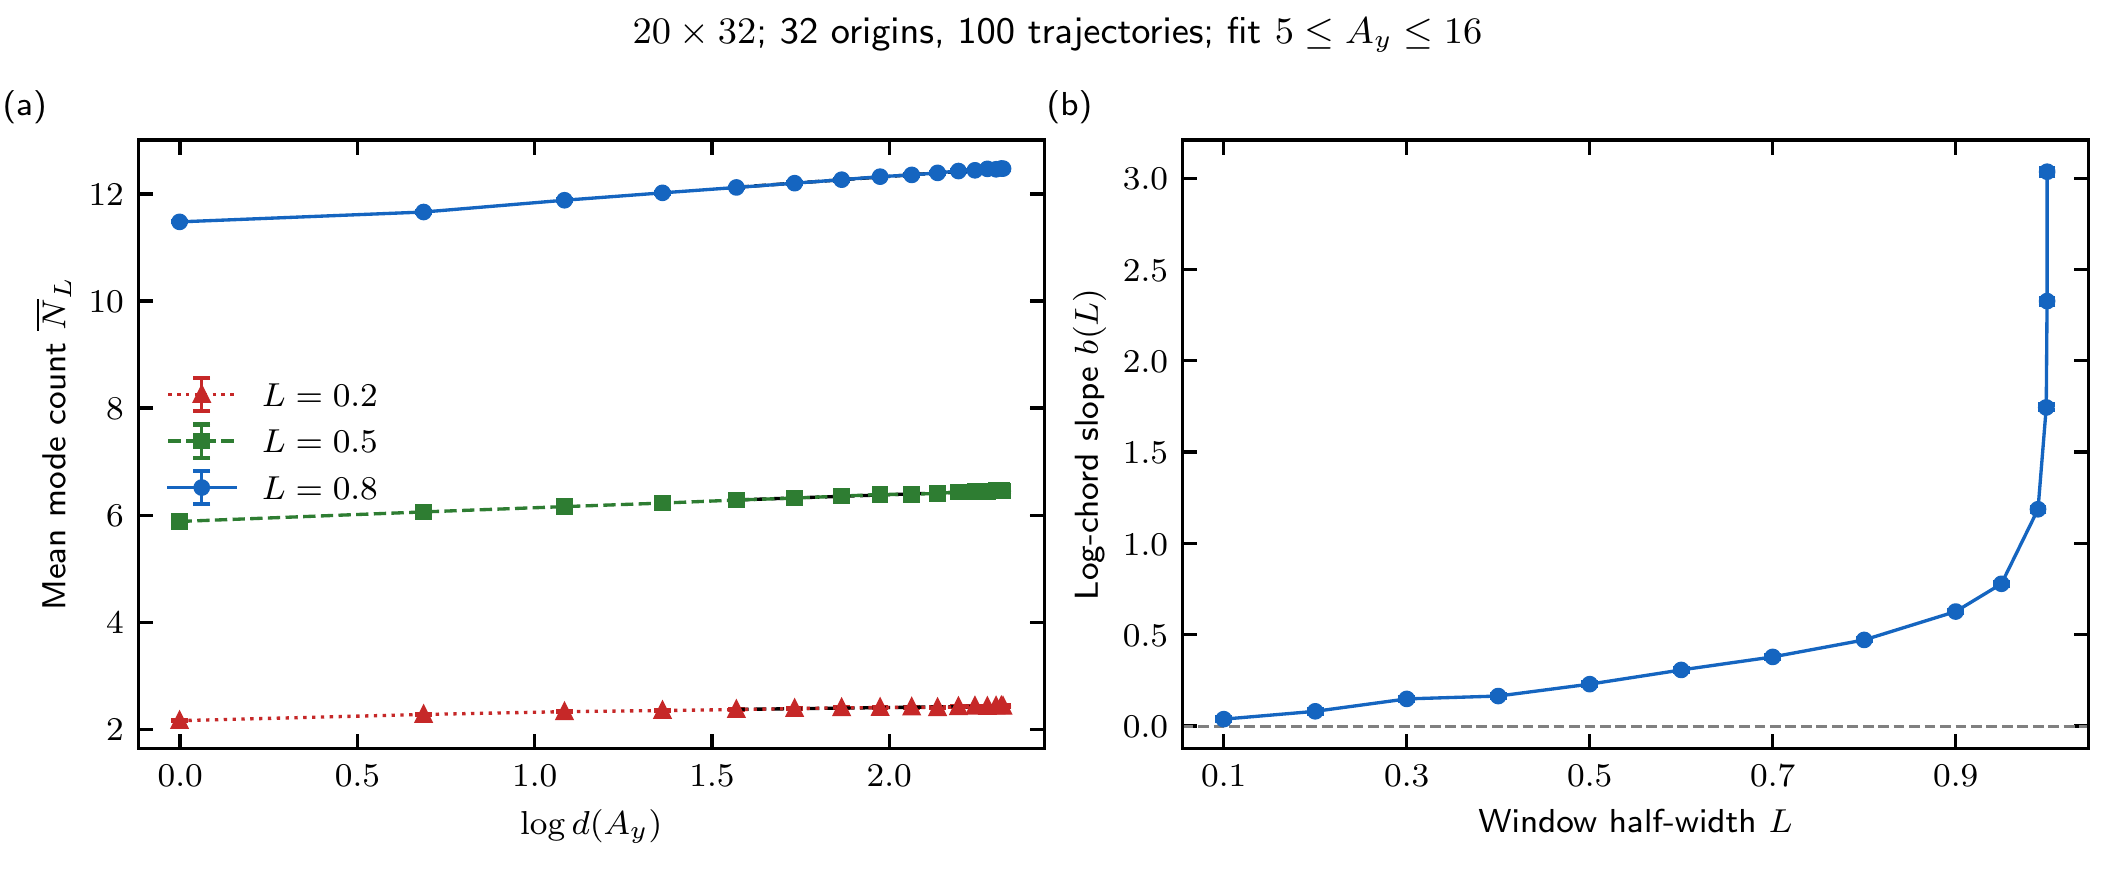

In [5]:
fig,axes=plt.subplots(1,2,figsize=(7.05,2.9))
styles=[('#c62828','^',':'),('#2e7d32','s','--'),('#1565c0','o','-')]
xx=np.linspace(log_chord[mask].min(),log_chord[mask].max(),150)
for L,(color,marker,style) in zip(DISPLAY_WINDOWS,styles):
    matches=np.flatnonzero(np.isclose(L_VALUES,L));
    if not len(matches):continue
    k=matches[0]
    axes[0].errorbar(log_chord,mean_counts[k],yerr=sem_counts[k],color=color,marker=marker,ls=style,
                     ms=3,lw=.8,capsize=2,label=r'$L=%.1f$'%L)
    axes[0].plot(xx,coefficients[k,0]+coefficients[k,1]*xx,color='black',ls='--',lw=.8)
axes[0].set(xlabel=r'$\log d(A_y)$',ylabel=r'Mean mode count $\overline N_L$')
axes[0].legend(frameon=False)
axes[1].errorbar(L_VALUES,coefficients[:,1],yerr=coefficient_sem[:,1],color='#1565c0',marker='o',ls='-',ms=3,capsize=2,lw=.8)
axes[1].axhline(0,color='gray',ls='--',lw=.7)
axes[1].set(xlabel=r'Window half-width $L$',ylabel=r'Log-chord slope $b(L)$',xticks=[.1,.3,.5,.7,.9])
for ax,letter in zip(axes,['(a)','(b)']):ax.text(-.15,1.04,letter,transform=ax.transAxes,fontweight='bold')
fig.suptitle(r'$20\times32$; 32 origins, 100 trajectories; fit $%d\leq A_y\leq%d$'%FIT_WIDTHS,fontsize=9)
export(fig,'window_dependence_summary')

## Standalone L = 0.99 fit
All 32 origins are averaged within each of the 100 trajectories. The figure shows every subsystem width 1–16 with open markers and trajectory SEM error bars. Gray marks the fitting window 5–16; the black dashed fit is extended across the full displayed range. The unshifted mean counts and two-parameter fit are retained.

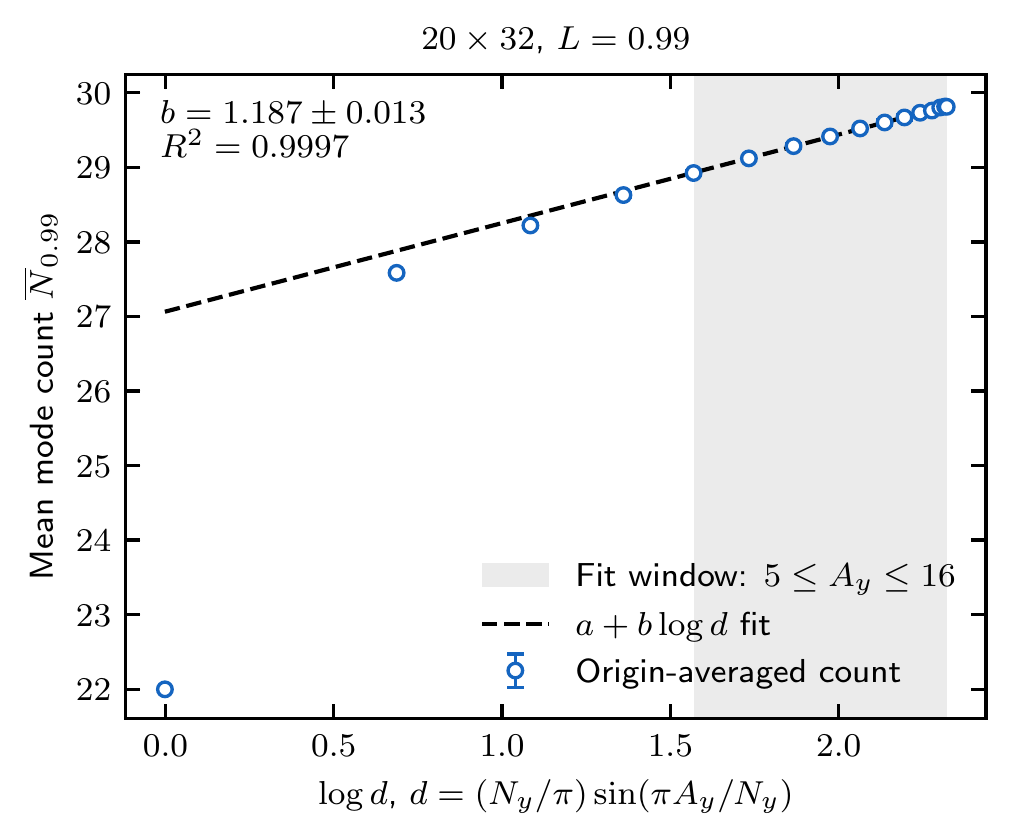

In [6]:
k=int(np.flatnonzero(np.isclose(L_VALUES,.99,rtol=0,atol=1e-14))[0])
fig,ax=plt.subplots(figsize=(3.375,2.8))
xx_single=np.linspace(log_chord.min(),log_chord.max(),250)
ax.axvspan(log_chord[mask].min(),log_chord[mask].max(),facecolor='0.92',edgecolor='none',zorder=0,
           label=r'Fit window: $%d\leq A_y\leq%d$'%FIT_WIDTHS)
ax.plot(xx_single,coefficients[k,0]+coefficients[k,1]*xx_single,color='black',ls='--',lw=1,zorder=1,label=r'$a+b\log d$ fit')
ax.errorbar(log_chord,mean_counts[k],yerr=sem_counts[k],color='#1565c0',marker='o',mfc='white',mec='#1565c0',mew=.8,
            ls='none',ms=3.5,capsize=2,elinewidth=.7,zorder=3,label='Origin-averaged count')
ax.set(xlabel=r'$\log d$, $d=(N_y/\pi)\sin(\pi A_y/N_y)$',ylabel=r'Mean mode count $\overline N_{0.99}$',
       title=r'$20\times32$, $L=0.99$')
ax.legend(frameon=False,loc='lower right',fontsize=8,handlelength=2)
ax.text(.04,.96,r'$b=%.3f\pm%.3f$'%(coefficients[k,1],coefficient_sem[k,1])+'\n'+r'$R^2=%.4f$'%r_squared[k],
        transform=ax.transAxes,ha='left',va='top',fontsize=8)
export(fig,'mean_mode_count_L099')

## Overlay of L = 0.99, 0.999, and 0.9999
All widths 1–16 are shown without shifting or rescaling the counts. Gray marks widths 5–16 used in each fit. Black dashed lines extend each fit over the full displayed range. The extra L=0.99999 window is included in the table, but not this overlay.

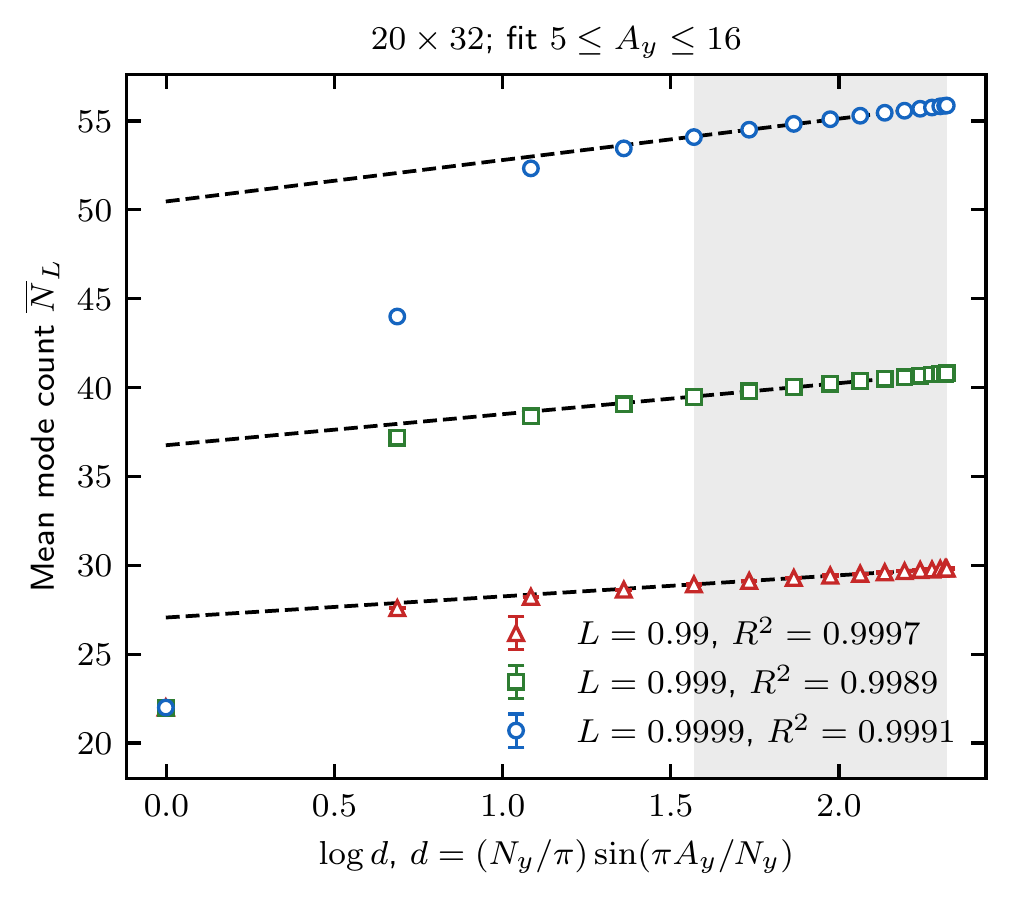

In [7]:
fig,ax=plt.subplots(figsize=(3.375,3.0))
xx_overlay=np.linspace(log_chord.min(),log_chord.max(),250)
ax.axvspan(log_chord[mask].min(),log_chord[mask].max(),facecolor='0.92',edgecolor='none',zorder=0)
for L,(color,marker) in zip([.99,.999,.9999],[('#c62828','^'),('#2e7d32','s'),('#1565c0','o')]):
    k=int(np.flatnonzero(np.isclose(L_VALUES,L,rtol=0,atol=1e-14))[0])
    ax.plot(xx_overlay,coefficients[k,0]+coefficients[k,1]*xx_overlay,color='black',ls='--',lw=.9,zorder=1)
    ax.errorbar(log_chord,mean_counts[k],yerr=sem_counts[k],color=color,marker=marker,mfc='white',mec=color,mew=.8,
                ls='none',ms=3.5,capsize=2,elinewidth=.7,zorder=3,label=r'$L=%.4g$, $R^2=%.4f$'%(L,r_squared[k]))
ax.set(xlabel=r'$\log d$, $d=(N_y/\pi)\sin(\pi A_y/N_y)$',ylabel=r'Mean mode count $\overline N_L$',
       title=r'$20\times32$; fit $%d\leq A_y\leq%d$'%FIT_WIDTHS)
ax.set_ylim(bottom=18) # leave room for the three fit statistics below the data
ax.legend(frameon=False,loc='lower right',fontsize=8)
export(fig,'mean_mode_count_near_endpoint_overlay')

## All fitted windows
Each panel zooms to the subsystem widths used in the fit. Vertical axes have independent limits so the small changes with chord length remain visible. Error bars are trajectory SEM. R-squared measures the mean curve only.

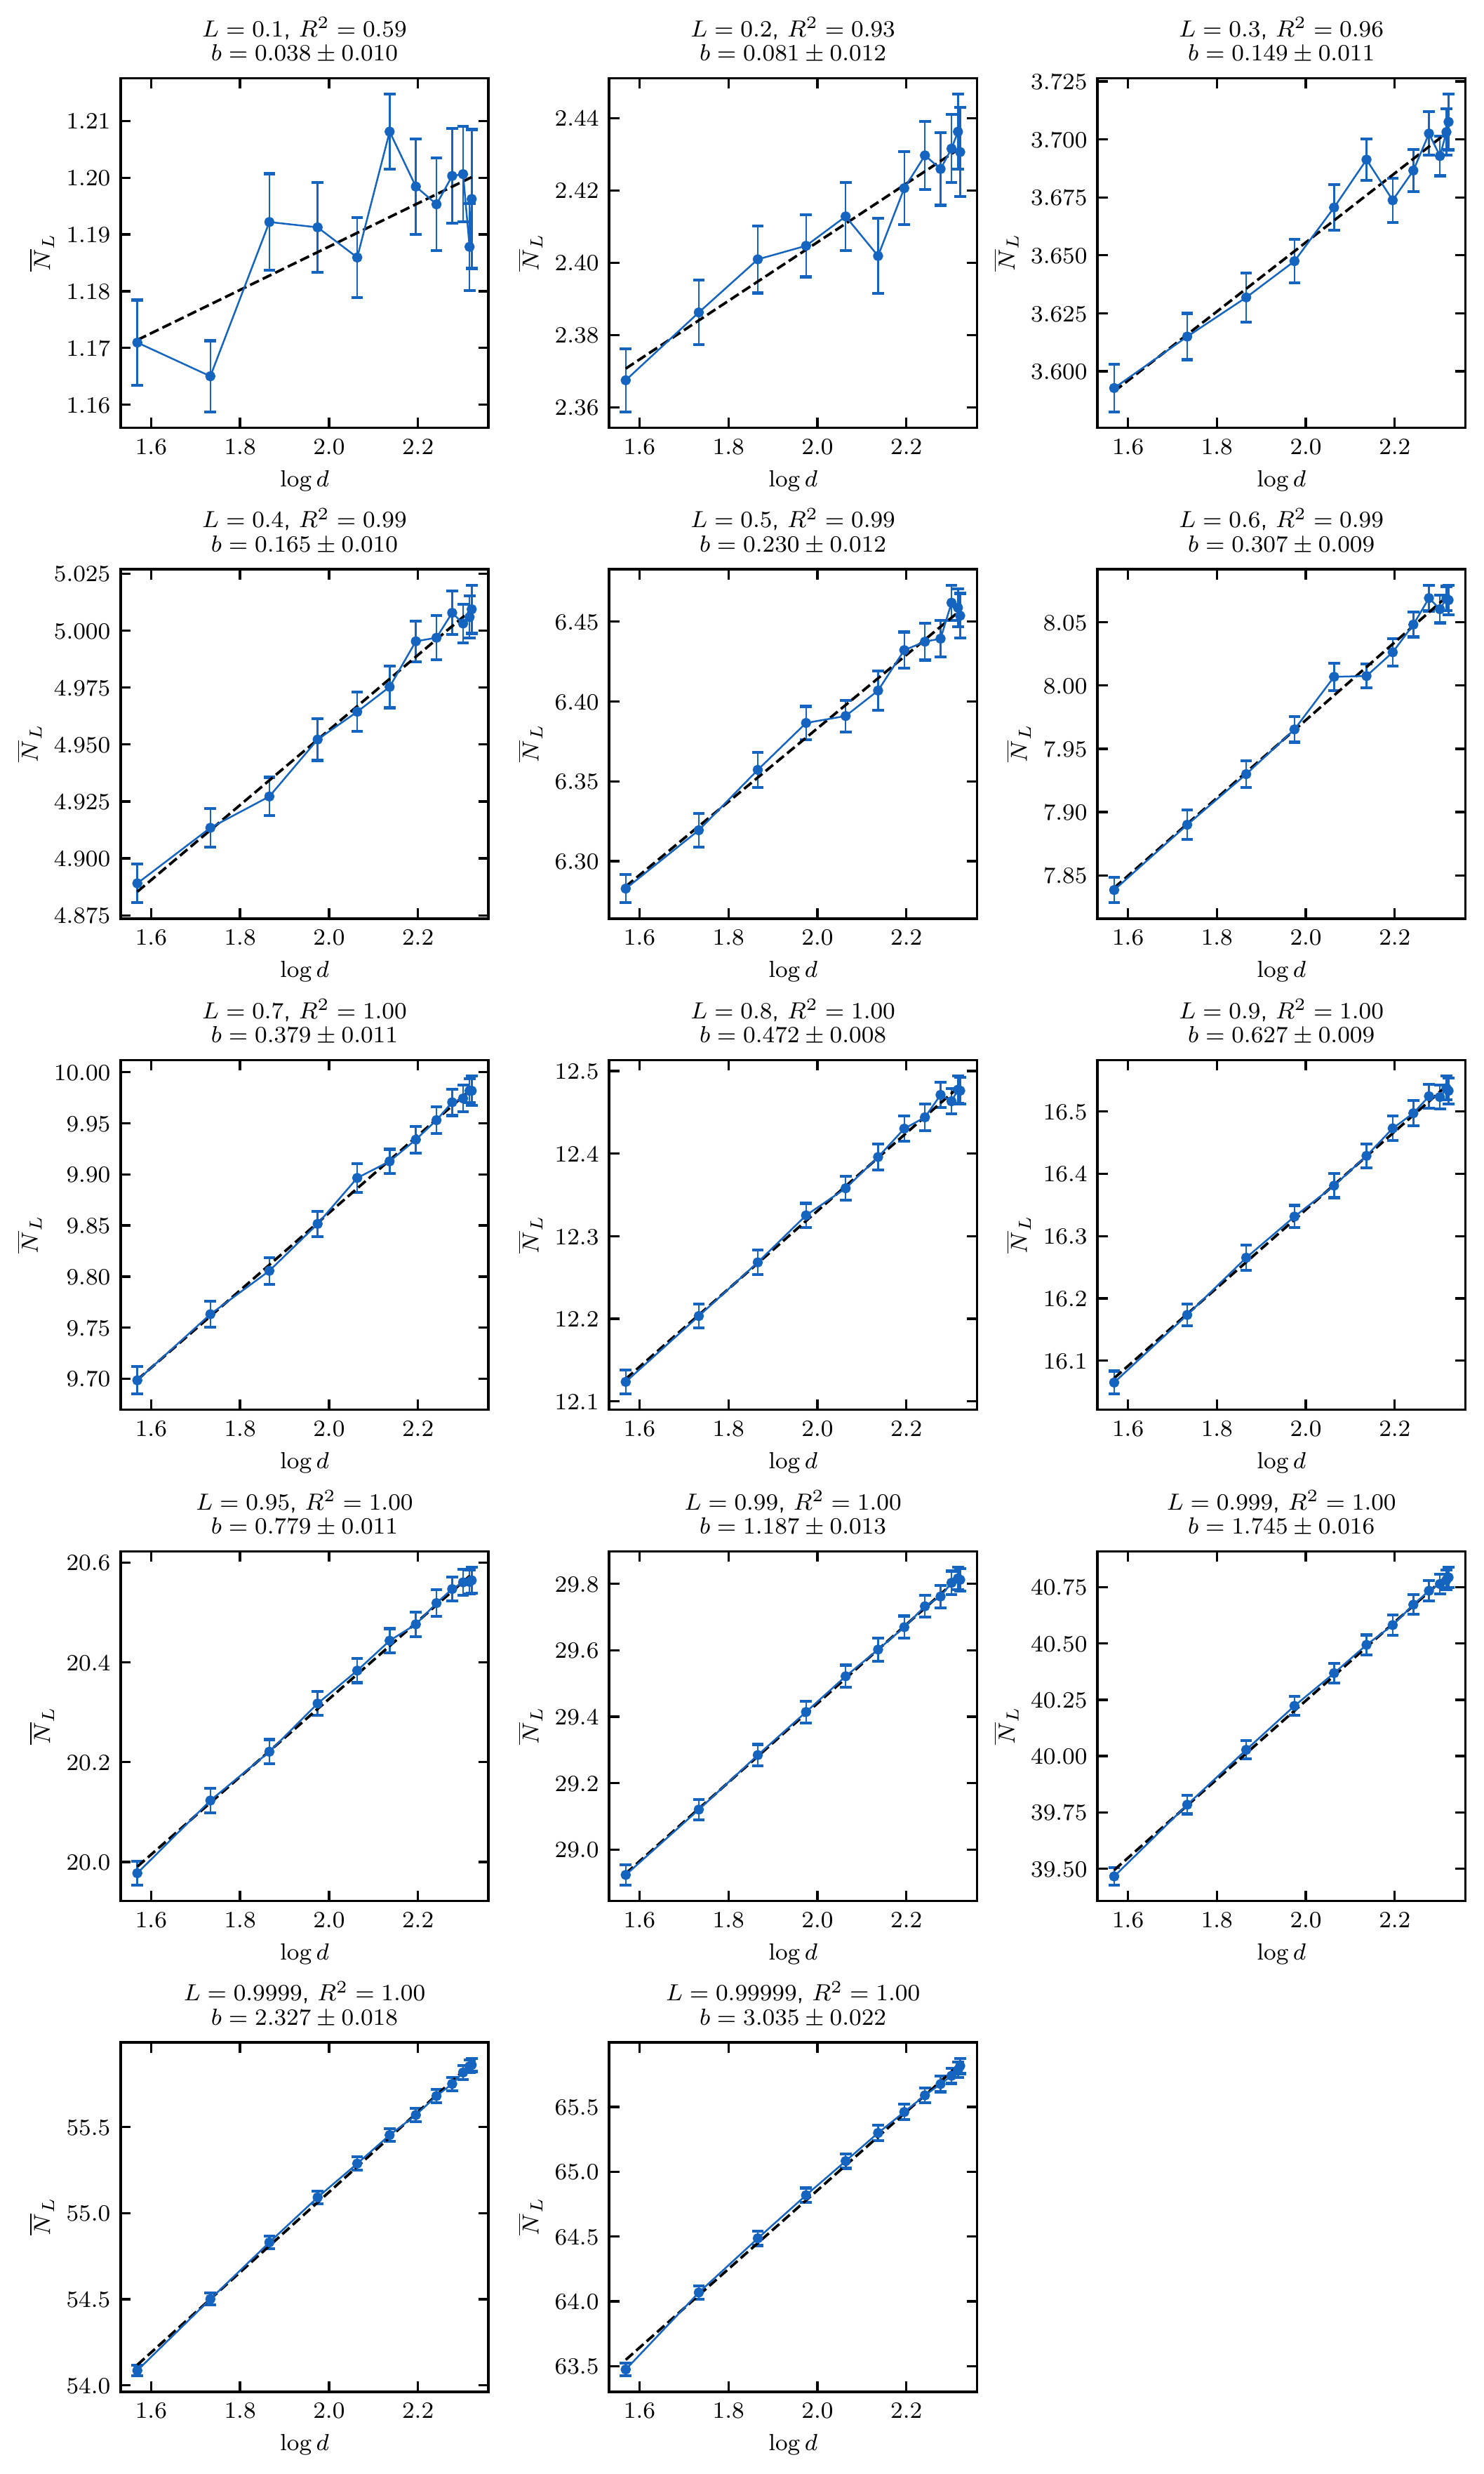

In [8]:
ncols=3;nrows=int(np.ceil(len(L_VALUES)/ncols))
fig,axes=plt.subplots(nrows,ncols,figsize=(7.05,2.35*nrows),squeeze=False)
for k,ax in enumerate(axes.flat):
    if k>=len(L_VALUES):ax.set_visible(False);continue
    ax.errorbar(log_chord[mask],mean_counts[k,mask],yerr=sem_counts[k,mask],color='#1565c0',marker='o',ls='-',ms=2.5,capsize=2,lw=.6)
    ax.plot(xx,coefficients[k,0]+coefficients[k,1]*xx,color='black',ls='--',lw=.9)
    ax.set_title(r'$L=%.5g$, $R^2=%.2f$'%(L_VALUES[k],r_squared[k])+'\n'+r'$b=%.3f\pm%.3f$'%(coefficients[k,1],coefficient_sem[k,1]),fontsize=8)
    ax.set(xlabel=r'$\log d$',ylabel=r'$\overline N_L$')
export(fig,'all_window_fits')

## Fit intercepts and residuals
Both fit coefficients vary with the spectral window. The residual RMS is in units of mean mode count and is provided alongside R-squared to avoid treating R-squared alone as evidence of a scaling law.

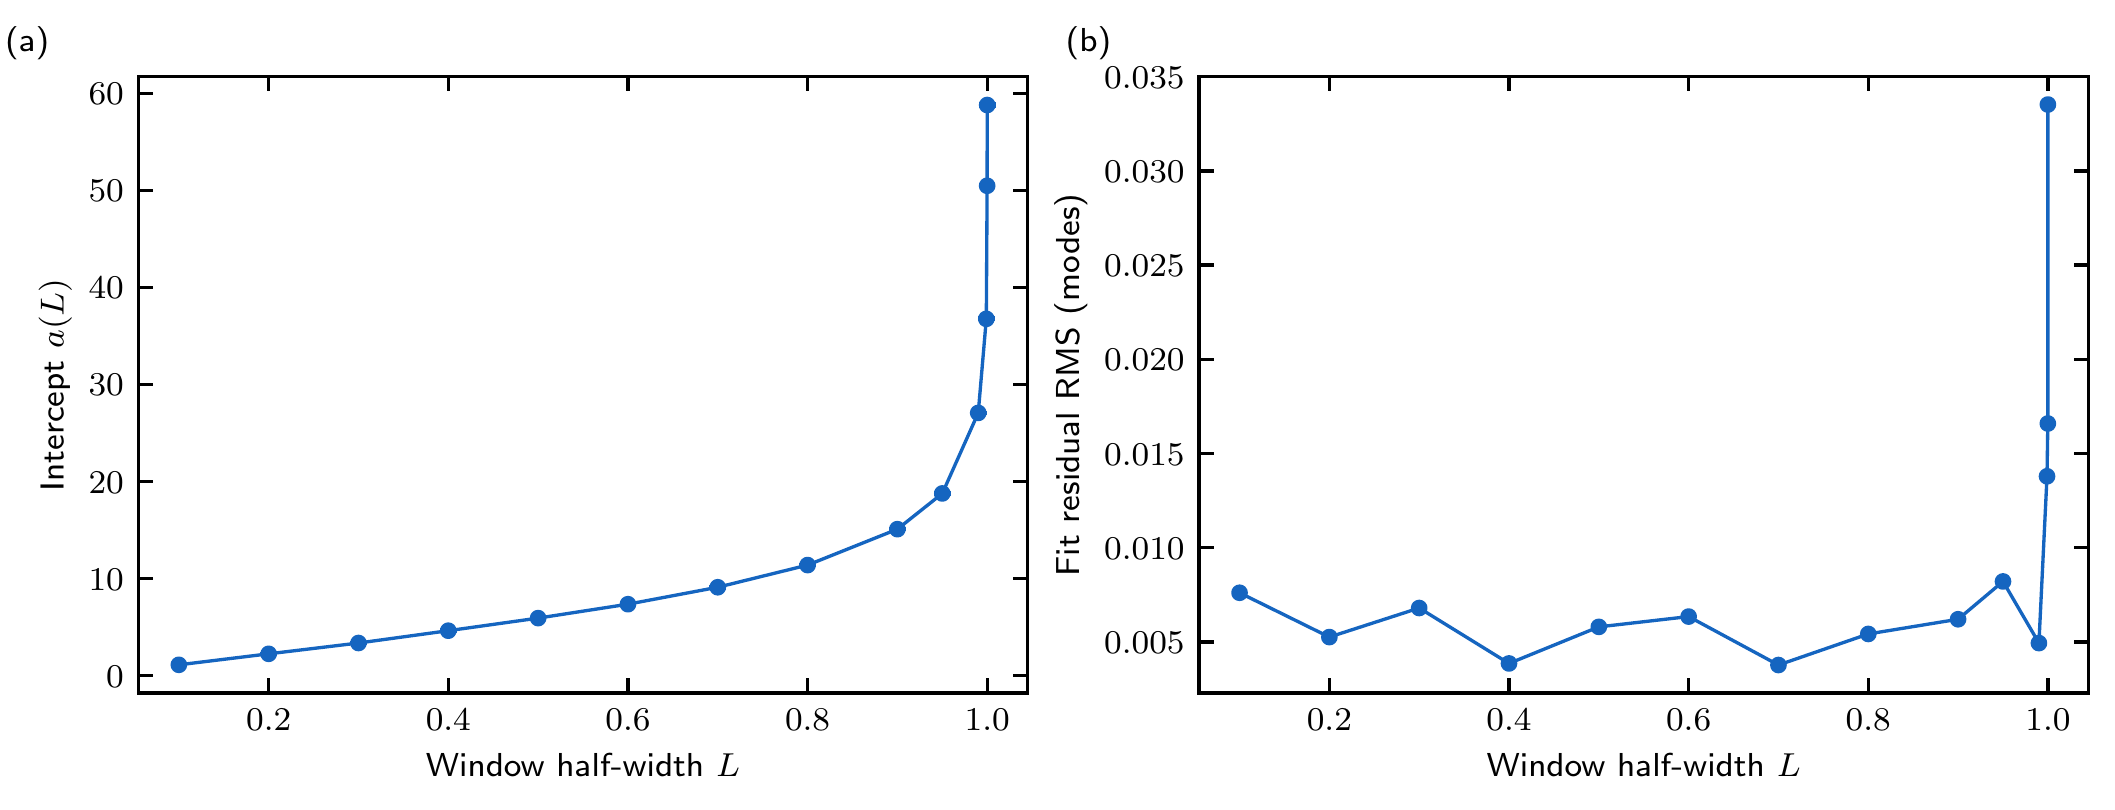

In [9]:
fig,axes=plt.subplots(1,2,figsize=(7.05,2.7))
axes[0].errorbar(L_VALUES,coefficients[:,0],yerr=coefficient_sem[:,0],color='#1565c0',marker='o',ls='-',ms=3,capsize=2,lw=.8)
axes[0].set(xlabel=r'Window half-width $L$',ylabel=r'Intercept $a(L)$')
axes[1].plot(L_VALUES,fits.residual_rms,color='#1565c0',marker='o',ms=3,lw=.8)
axes[1].set(xlabel=r'Window half-width $L$',ylabel='Fit residual RMS (modes)')
for ax,letter in zip(axes,['(a)','(b)']):ax.text(-.15,1.04,letter,transform=ax.transAxes,fontweight='bold')
export(fig,'window_fit_diagnostics')

Caption: S=100 independent hard-wall trajectories at Nx=20, Ny=32, alpha1=1, alpha2=30, nshell=1, initialized as pure states with the exterior prepared as a product frame; saved endpoints at cycle 64. Each subsystem contains all x, both orbitals, and Ay consecutive periodic y rows. Count centered covariance eigenvalues in [-L,L] per origin, average the 32 origins inside each trajectory, then average trajectories. No normalization by mode number is applied. Error bars are one trajectory SEM. Fits use Ay=5–16 and natural log chord length; full cross-width correlations are retained in coefficient uncertainties. Different windows are correlated because they use the same trajectories.

## Numerical diagnostics and completion

In [10]:
print(json.dumps(checks,indent=2))
print(fits.to_string(index=False))
report='# Mean mode count: spectral-window scan\n\n'+json.dumps(config,indent=2)+'\n\n'
report+='Fit model: mean N_L = a(L) + b(L) log[(32/pi) sin(pi Ay/32)]. Coefficient uncertainties are SEMs of fits to the 100 trajectory-level origin averages. All fits are descriptive, with correlated widths and windows.\n\n'
report+=fits.to_string(index=False)+'\n\n'
report+='Outputs: all_windows_summary.csv (all windows with half-system central counts and full/subsystem percentages); mean_mode_counts.csv; window_fit_summary.csv; window_scan_statistics.npz (counts, trajectory averages, coefficients and joint covariance); input_provenance.json; window_scan_diagnostics.json; five PDF/PNG figure pairs, including the standalone L=0.99 fit and the three-window near-endpoint overlay; the earlier L=0.9 figure is also preserved. The validated spectrum cache stays in the adjacent source directory.\n'
(OUT/'README.md').write_text(report)
print('Completed window scan; L_VALUES and FIT_WIDTHS remain editable.')

{
  "raw_min": -1.000000000000013,
  "raw_max": 1.0000000000000417,
  "count_monotonic_in_L": true,
  "half_width_complement_counts_equal": true,
  "independent_trajectories": 100,
  "coefficient_covariance_flatten_order": "window, then [intercept,slope]",
  "L05_max_count_difference": 0.0
}
      L  intercept  intercept_sem    slope  slope_sem  R_squared  residual_rms  max_abs_residual  fit_min_width  fit_max_width  percentage_reference_Ay  mean_modes_at_reference_Ay  mean_modes_sem_at_reference_Ay  percent_of_full_system_modes  percent_of_full_system_modes_sem  percent_of_subsystem_modes  percent_of_subsystem_modes_sem
0.10000   1.111501       0.020514 0.038174   0.010132   0.588983      0.007608          0.015068              5             16                       16                    1.196250                        0.012246                      0.093457                          0.000957                    0.186914                        0.001913
0.20000   2.243548       0.025896 0

## L = 0.99: subsystem modes by width and equal-width average
For each width 5–16, count centered eigenvalues in [-0.99,0.99] and divide by that subsystem’s 40 Ay modes to obtain its percentage. The final row averages widths equally. It is a mean of percentages, not a ratio of pooled counts. Statistical errors retain all cut and width correlations within each trajectory.

In [11]:
from pathlib import Path
import numpy as np
import pandas as pd
import json
from IPython.display import display
OUT=Path.cwd()
with np.load(OUT/'window_scan_statistics.npz') as z:
    k=int(np.flatnonzero(np.isclose(z['L_values'],.99,rtol=0,atol=1e-14))[0])
    selected=(z['widths']>=5)&(z['widths']<=16)
    ay=z['widths'][selected]
    per_trajectory=z['trajectory_counts'][:,k,selected]
    direct=z['counts'][:,k,selected,:].mean(-1)
assert np.array_equal(per_trajectory,direct)
mode_counts=40*ay
per_trajectory_percent=100*per_trajectory/mode_counts
rows=pd.DataFrame(dict(Ay=ay,subsystem_modes=mode_counts,
 mean_window_modes=per_trajectory.mean(0),mean_window_modes_sem=per_trajectory.std(0,ddof=1)/10,
 subsystem_percent=per_trajectory_percent.mean(0),subsystem_percent_sem=per_trajectory_percent.std(0,ddof=1)/10))
average_count=per_trajectory.mean(1)
average_percent=per_trajectory_percent.mean(1)
avg=dict(Ay='5–16 mean',subsystem_modes=np.nan,
 mean_window_modes=float(average_count.mean()),mean_window_modes_sem=float(average_count.std(ddof=1)/10),
 subsystem_percent=float(average_percent.mean()),subsystem_percent_sem=float(average_percent.std(ddof=1)/10))
assert np.isclose(avg['subsystem_percent'],rows.subsystem_percent.mean())
result=pd.concat([rows,pd.DataFrame([avg])],ignore_index=True)
result.insert(0,'L',.99)
result.to_csv(OUT/'L099_subsystem_modes_by_width.csv',index=False)
diagnostics=dict(L=.99,widths=ay.tolist(),samples=100,origins=32,
 estimator='average origins within trajectory, then trajectories; final row averages widths equally',
 percentage='100 * mean window count / (40 Ay), calculated separately per width before equal-width averaging',
 uncertainty='SEM across 100 independent trajectories after origin and (for final row) width averaging',
 average=avg)
# The mean row has no single subsystem size.
diagnostics['average']['subsystem_modes']=None
(OUT/'L099_subsystem_modes_by_width.json').write_text(json.dumps(diagnostics,indent=2)+'\n')
display(result[['Ay','subsystem_modes','mean_window_modes','subsystem_percent']].round(4))


,Ay,subsystem_modes,mean_window_modes,subsystem_percent
0,5,200.0,28.9238,14.4619
1,6,240.0,29.1203,12.1335
2,7,280.0,29.2844,10.4587
3,8,320.0,29.4141,9.1919
4,9,360.0,29.5216,8.2004
5,10,400.0,29.6019,7.4005
6,11,440.0,29.6694,6.7430
7,12,480.0,29.7322,6.1942
8,13,520.0,29.7616,5.7234
9,14,560.0,29.8028,5.3219


## R-squared versus spectral window size
Both panels show all 14 tested windows, including L=0.99999, using mode-count fits over Ay=5–16. Both vertical axes show 1-R-squared on a logarithmic scale. The left horizontal axis shows L on a linear scale; the right shows 1-L on a logarithmic scale. Lines guide the eye. These are R-squared values for fits to ensemble means, not probabilities or independent samples; each mean averages 32 origins inside each of 100 trajectories.

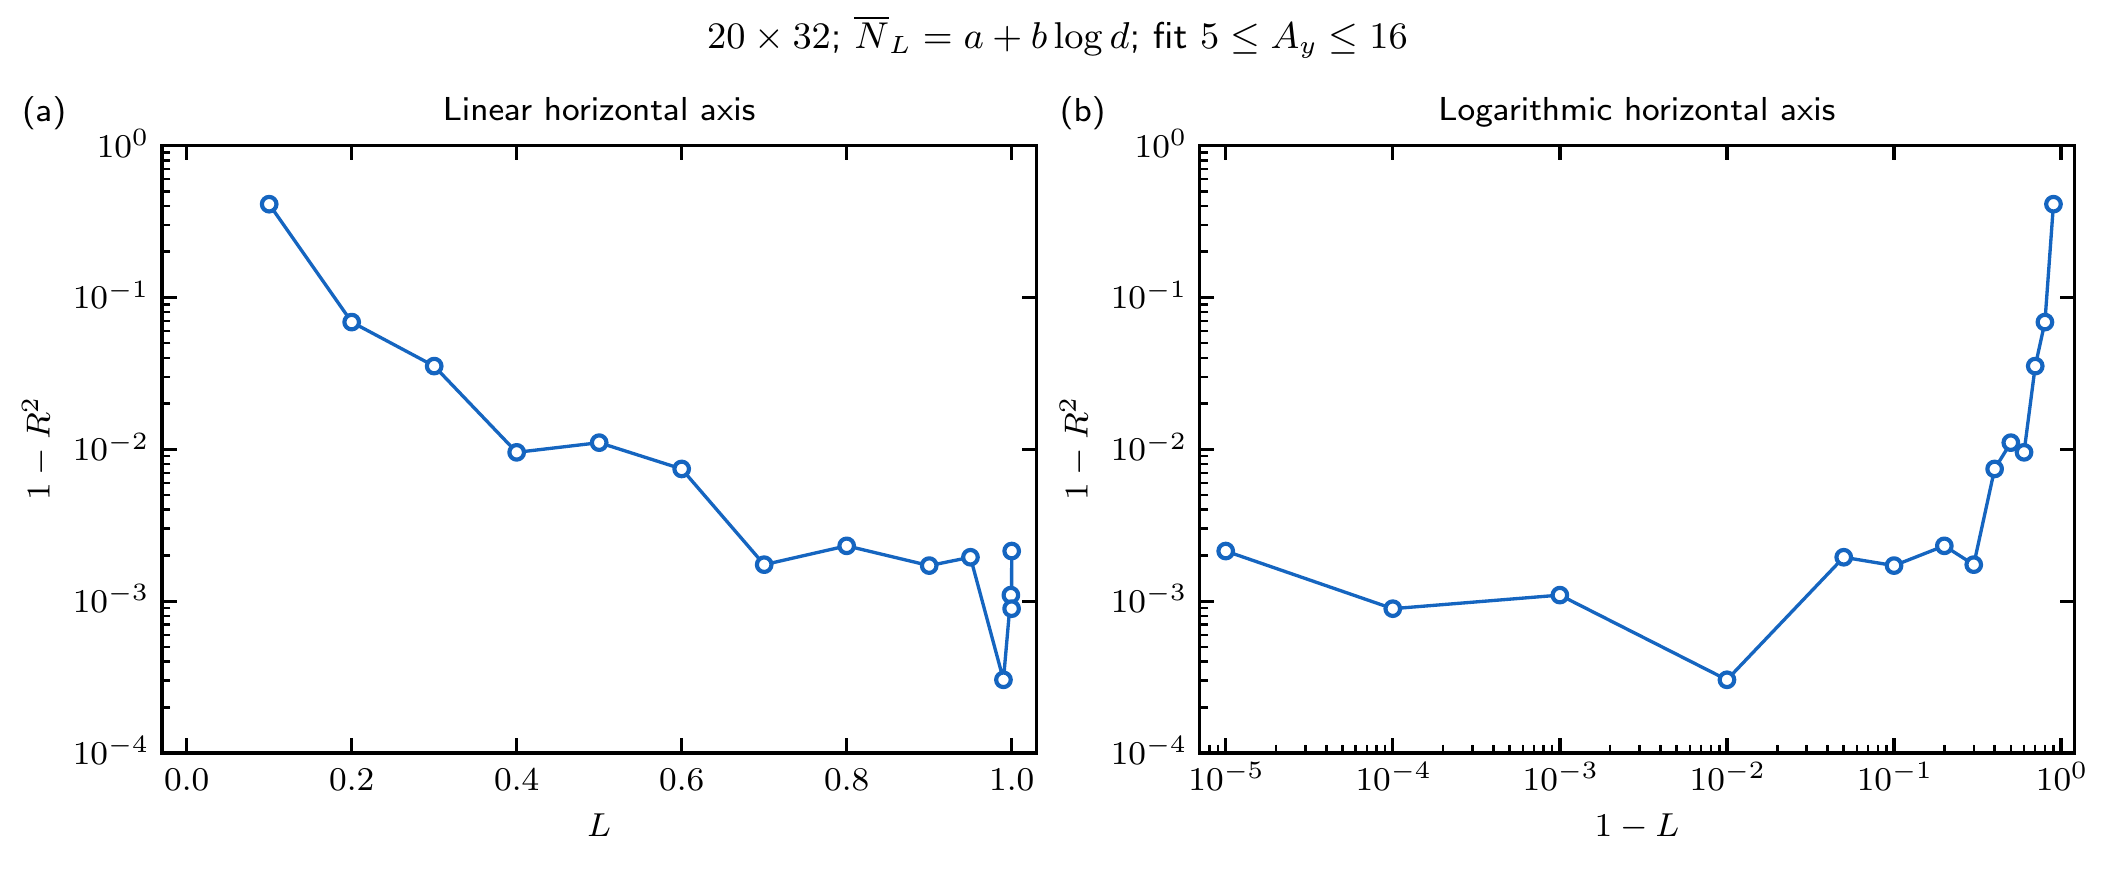

In [16]:
from pathlib import Path
import os,json,subprocess
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from IPython.display import display,Image
OUT=Path.cwd()
r2_table=pd.read_csv(OUT/'window_fit_summary.csv')
assert (r2_table.fit_min_width==5).all() and (r2_table.fit_max_width==16).all()
assert np.any(np.isclose(r2_table.L,.99999,rtol=0,atol=1e-14))
with np.load(OUT/'window_scan_statistics.npz') as z:
    selected=(z['widths']>=5)&(z['widths']<=16)
    x=np.log(32/np.pi*np.sin(np.pi*z['widths'][selected]/32))
    y=z['mean_counts'][:,selected]
    prediction=r2_table.intercept.to_numpy()[:,None]+r2_table.slope.to_numpy()[:,None]*x
    r2_check=1-((y-prediction)**2).sum(1)/((y-y.mean(1,keepdims=True))**2).sum(1)
assert np.allclose(r2_check,r2_table.R_squared,rtol=0,atol=1e-12)
r2_table['one_minus_L']=1-r2_table.L
r2_table['one_minus_R_squared']=1-r2_table.R_squared
assert (r2_table.one_minus_R_squared>0).all()
r2_table[['L','one_minus_L','R_squared','one_minus_R_squared','fit_min_width','fit_max_width']].to_csv(OUT/'R_squared_vs_window_size.csv',index=False)
os.environ['TEXINPUTS']=str(OUT/'latex_support')+os.pathsep+os.environ.get('TEXINPUTS','')
mpl.rcParams.update({'font.family':'sans-serif','font.sans-serif':['CMU Sans Serif'],'font.size':8,
 'axes.labelsize':8,'axes.titlesize':8,'xtick.labelsize':8,'ytick.labelsize':8,'text.usetex':True,
 'pdf.fonttype':42,'xtick.direction':'in','ytick.direction':'in'})
fig,axes=plt.subplots(1,2,figsize=(7.05,2.9))
for ax,letter,scale,title in zip(axes,['(a)','(b)'],['linear','log'],['Linear horizontal axis','Logarithmic horizontal axis']):
    x = r2_table.L if scale == 'linear' else r2_table.one_minus_L
    ax.plot(x,r2_table.one_minus_R_squared,'o-',color='#1565c0',mfc='white',ms=3.5,lw=.8)
    ax.set(xlabel=(r'$L$' if scale == 'linear' else r'$1-L$'),ylabel=r'$1-R^2$',xscale=scale,yscale='log',title=title,ylim=(1e-4,1))
    ax.tick_params(top=True,right=True)
    ax.text(-.16,1.04,letter,transform=ax.transAxes,fontweight='bold')
axes[0].set_xlim(-.03,1.03)
axes[0].set_xticks([0,.2,.4,.6,.8,1.])
axes[1].set_xlim(7e-6,1.2)
fig.suptitle(r'$20\times32$; $\overline N_L=a+b\log d$; fit $5\leq A_y\leq16$',fontsize=9)
fig.tight_layout(pad=.8)
fig.savefig(OUT/'R_squared_vs_window_size.pdf');plt.close(fig)
subprocess.run(['pdftoppm','-r','300','-singlefile','-png',str(OUT/'R_squared_vs_window_size.pdf'),str(OUT/'R_squared_vs_window_size')],check=True)
display(Image(filename=str(OUT/'R_squared_vs_window_size.png'),width=950))
